Question 1:<br>
Variables:<br>
V(H, P, D) where: <br>
H ∈ {H1, ..., H14}<br>
P ∈ {P1, P2, P3, P4}<br>
D ∈ {Sunday, Monday, Tuesday, Wednesday, Thursday}<br>
Each variable represents the assignment of a proctor R to a specific hall H in period P of day D<br>
Total number of variables: 14 halls * 4 periods * 5 days = 280 variables<br>
Domains:<br>
D(V) = {R1, R2, ..., R30}<br>
Constraints:<br>
1. V(H, D, P) ∈ AvailableProctors(D)
2. Count (V(H, D, P) = Ri) ≤ 3  for all P and H on day D
3. V(H1, D1, P1) ≠ V(H2, D2, P2)  for all H1 ≠ H2, D1 = D2, P1 = P2
4. H1 ≠ H2  for all V(H1, D1, P1) = V(H2, D2, P2), P1 ≠ P2, D1 = D2
5. ∀ H, D, P,  Ǝ V(H, D, P)

Question 2: <br>
The problem is infeasilbe because the total number of required assignments is 280, and the possible assignments under the given constraints is 30 procators * 3 days * 3 periods = 270. There is a gap of 10 slots. <br>
We have 3 options to solve this: 
1. Increase number of procators to 32.
2. Increase working days to 4 for each procator.
3. Increase daily limit to 4 periods for each procator. <br>
Options 2 and 3 will increase the problem size to 360 variables with tighter constraints. We will go with option 1 as to leave the variables the same and widen the domain of procators for each variable

Note: Unary Constraint C1 (Work Days) is implicit in the domain of each node.


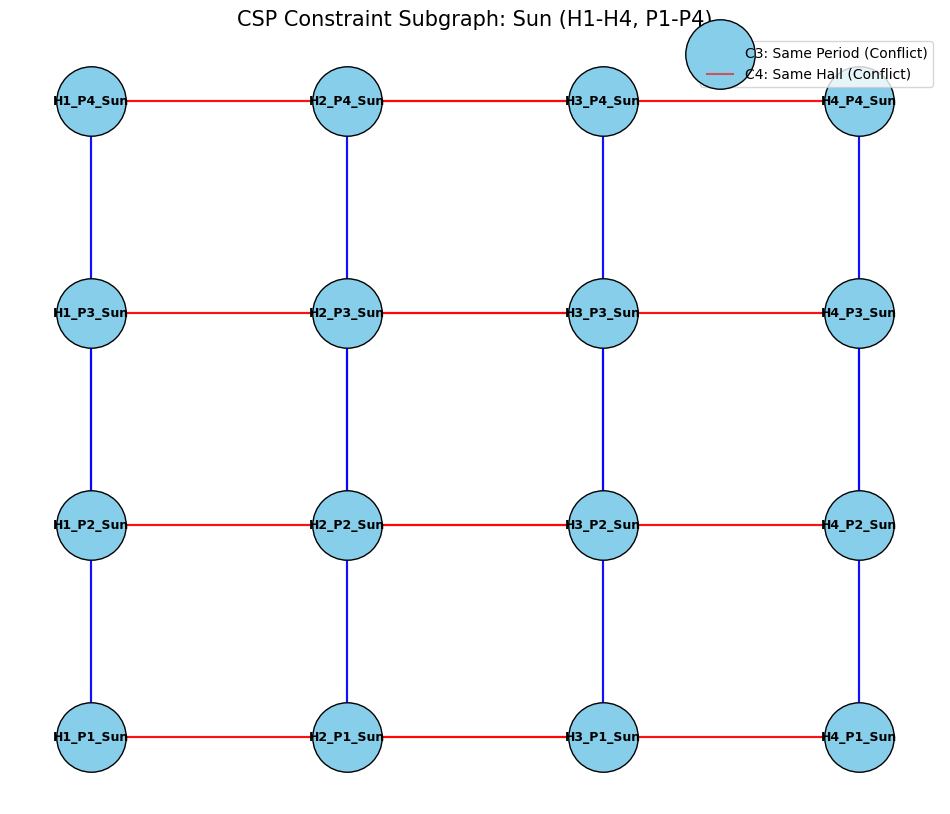

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Initialize the graph
G = nx.Graph()

# Setup parameters
day = "Sun"
periods = ["P1", "P2", "P3", "P4"]
halls = ["H1", "H2", "H3", "H4"]

# 1. Define Nodes (Variables) 
# Each node represents a (Day, Period, Hall) slot
nodes = [f"{h}_{p}_{day}" for p in periods for h in halls]
G.add_nodes_from(nodes)

# 2. Define Edges (Constraints) [cite: 13]
for p in periods:
    for h in halls:
        current_node = f"{h}_{p}_{day}"
        
        # Constraint C3: No Time Overlap 
        # A proctor cannot be in two halls at the same time
        for other_h in halls:
            if h != other_h:
                G.add_edge(current_node, f"{other_h}_{p}_{day}", label='C3')
        
        # Constraint C4: Different Halls 
        # A proctor cannot monitor the same hall twice in one day
        for other_p in periods:
            if p != other_p:
                G.add_edge(current_node, f"{h}_{other_p}_{day}", label='C4')

# 3. Plotting
plt.figure(figsize=(12, 10))

# Position nodes in a grid for readability
pos = {f"{h}_{p}_{day}": (i, j) for j, p in enumerate(periods) for i, h in enumerate(halls)}

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=2500, node_color='skyblue', edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

# Draw edges with different styles for C3 and C4
c3_edges = [(u, v) for u, v, d in G.edges(data=True) if d['label'] == 'C3']
c4_edges = [(u, v) for u, v, d in G.edges(data=True) if d['label'] == 'C4']

nx.draw_networkx_edges(G, pos, edgelist=c3_edges, edge_color='red', width=1.5, alpha=0.6, label='C3: Time Conflict')
nx.draw_networkx_edges(G, pos, edgelist=c4_edges, edge_color='blue', width=1.5, alpha=0.6, label='C4: Hall Conflict')

# Add a legend and title
plt.title(f"CSP Constraint Subgraph: {day} (H1-H4, P1-P4)", fontsize=15)
plt.legend(['C3: Same Period (Conflict)', 'C4: Same Hall (Conflict)'], loc='upper right', scatterpoints=1)
plt.axis('off')

# Note on Unary Constraints (C1) 
print("Note: Unary Constraint C1 (Work Days) is implicit in the domain of each node.")

plt.show()

Question 3:Standard backtracking algorithm 

In [73]:
import time

# --- 1. Problem Configuration ---
DAYS = ['Sun', 'Mon', 'Tue','wed', 'Thu']
PERIODS = ['P1', 'P2', 'P3', 'P4']
HALLS = [f'H{i}' for i in range(1, 10)] 
PROCTORS = [f'R{i}' for i in range(1,27)] 

# All variables to be assigned
VARIABLES = [(h, p, d) for h in HALLS for p in PERIODS for d in DAYS]

# Constraints Data
proctor_schedules = {f'R{i}': [DAYS[i%5], DAYS[(i+1)%5], DAYS[(i+2)%5]] for i in range(1, 27)}
# State Tracking
proctor_daily_load = {(d, r): 0 for d in DAYS for r in PROCTORS}
proctor_busy_period = {(d, p, r): False for d in DAYS for p in PERIODS for r in PROCTORS}
proctor_hall_history = {(d, h, r): False for d in DAYS for h in HALLS for r in PROCTORS}

stats = {
    "nodes_explored": 0,
    "bt_count": 0
}

def find_unassigned(assignment):
    """Equivalent to find_empty in Sudoku code."""
    for var in VARIABLES:
        if var not in assignment:
            return var
    return None

def is_valid(var, proctor, assignment):
    """Equivalent to is_valid in Sudoku code."""
    hall, period, day = var
    
    if day not in proctor_schedules[proctor]:
        return False
    if proctor_daily_load[(day, proctor)] >= 3:
        return False
    if proctor_busy_period[(day, period, proctor)]:
        return False
    if proctor_hall_history[(day, hall, proctor)]:
        return False
                
    return True

def backtrack(assignment, stats):
    """The core recursive function following the sudoku_bt.py structure."""
    stats["nodes_explored"] += 1
    
    # 1. Find next unassigned slot
    next_var = find_unassigned(assignment)
    
    # 2. Base Case: If no unassigned slots remain, we are done
    if not next_var:
        return assignment
    
    # 3. Try each Proctor (Equivalent to 'for val in VALUES')
    for proctor in PROCTORS:
        if is_valid(next_var, proctor, assignment):
            # Place
            assignment[next_var] = proctor
            
            # Update state trackers
            hall, period, day = next_var
            proctor_daily_load[(day, proctor)] += 1
            proctor_busy_period[(day, period, proctor)] = True
            proctor_hall_history[(day, hall, proctor)] = True
            
            # Recurse
            result = backtrack(assignment, stats)
            if result:
                return result
            
            # Backtrack (Undo state trackers)
            proctor_daily_load[(day, proctor)] -= 1
            proctor_busy_period[(day, period, proctor)] = False
            proctor_hall_history[(day, hall, proctor)] = False
            print("louay")
            del assignment[next_var]
            
    # If no proctors work, increment backtrack count and return None
    stats["bt_count"] += 1
    return None

# --- 4. Execution ---
print("=" * 40)
print("Exam Scheduling Backtracking Search")
print("=" * 40)

start_time = time.time()
final_solution = backtrack({}, stats)
end_time = time.time()

if final_solution:
    print(f"SUCCESS: Found in {end_time - start_time:.2f} seconds.")
    print(f"Nodes Explored: {stats['nodes_explored']}")
    print(f"Backtrack Count: {stats['bt_count']}")
    
    print("\nSample Solution (First 20):")
    for var in VARIABLES[:20]:  # Print first 100 assignments for brevity  
        print(f"  Slot {var} -> Assigned: {final_solution[var]}")
else:
    print("FAILURE: No solution exists.")

Exam Scheduling Backtracking Search
SUCCESS: Found in 0.00 seconds.
Nodes Explored: 181
Backtrack Count: 0

Sample Solution (First 20):
  Slot ('H1', 'P1', 'Sun') -> Assigned: R3
  Slot ('H1', 'P1', 'Mon') -> Assigned: R1
  Slot ('H1', 'P1', 'Tue') -> Assigned: R1
  Slot ('H1', 'P1', 'wed') -> Assigned: R1
  Slot ('H1', 'P1', 'Thu') -> Assigned: R2
  Slot ('H1', 'P2', 'Sun') -> Assigned: R4
  Slot ('H1', 'P2', 'Mon') -> Assigned: R4
  Slot ('H1', 'P2', 'Tue') -> Assigned: R2
  Slot ('H1', 'P2', 'wed') -> Assigned: R2
  Slot ('H1', 'P2', 'Thu') -> Assigned: R3
  Slot ('H1', 'P3', 'Sun') -> Assigned: R5
  Slot ('H1', 'P3', 'Mon') -> Assigned: R5
  Slot ('H1', 'P3', 'Tue') -> Assigned: R5
  Slot ('H1', 'P3', 'wed') -> Assigned: R3
  Slot ('H1', 'P3', 'Thu') -> Assigned: R4
  Slot ('H1', 'P4', 'Sun') -> Assigned: R8
  Slot ('H1', 'P4', 'Mon') -> Assigned: R6
  Slot ('H1', 'P4', 'Tue') -> Assigned: R6
  Slot ('H1', 'P4', 'wed') -> Assigned: R6
  Slot ('H1', 'P4', 'Thu') -> Assigned: R7


Search tree:
Rectangles (Nodes): Represent the state of the assignment at a specific point in time.<br>
Salmon/Red Nodes: These are the Failure Points.  where a proctor assignment violated a rule (e.g., $R1$ not working on Sunday).<br>
Green Nodes: These are the paths the algorithm successfully took to move to the next variable.<br>
Backtracking (Implicit): In the code's output, a backtrack is the movement from a Salmon node back up to the Grey/Blue parent to try a different value.<br>

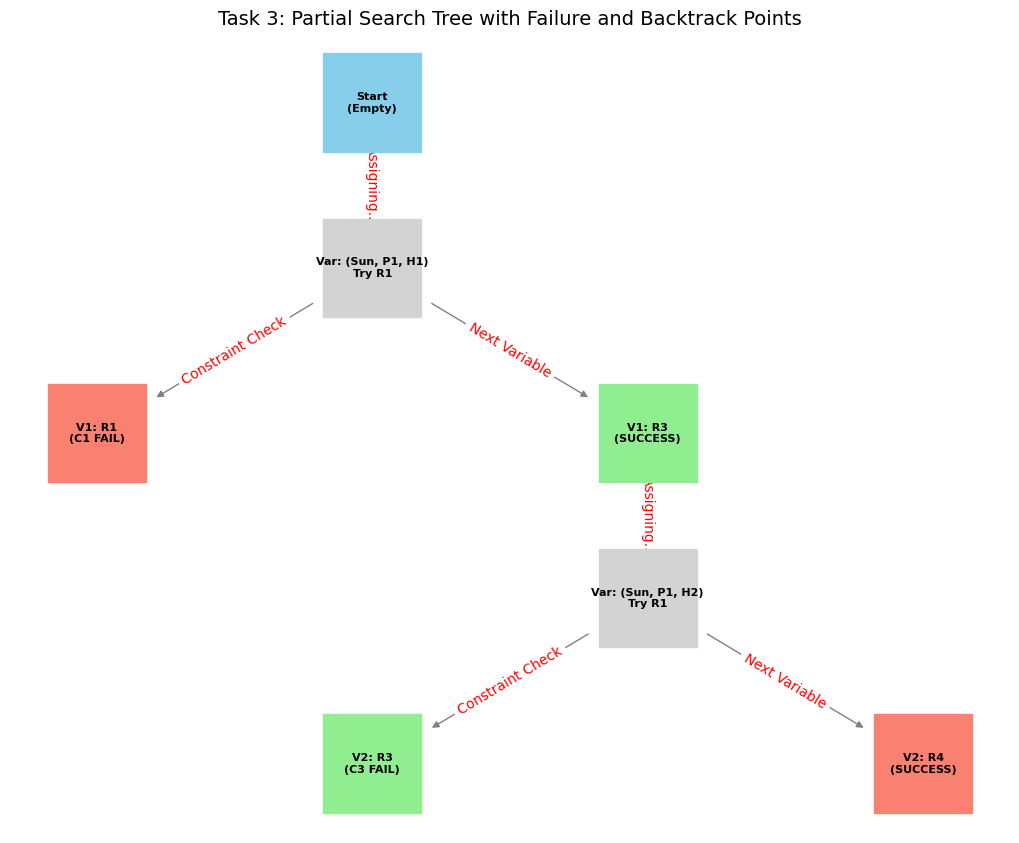

In [30]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_partial_search_tree():
    G = nx.DiGraph()
    
    # Define Nodes: (Variable, Value/Status)
    nodes = {
        "Root": "Start\n(Empty)",
        "V1": "Var: (Sun, P1, H1)\nTry R1",
        "V1_Fail": "V1: R1\n(C1 FAIL)",
        "V1_Success": "V1: R3\n(SUCCESS)",
        "V2": "Var: (Sun, P1, H2)\nTry R1",
        "V2_Success": "V2: R4\n(SUCCESS)",
        "V2_Backtrack": "V2: R3\n(C3 FAIL)"
    }
    
    # Add nodes with labels
    for node, label in nodes.items():
        G.add_node(node, label=label)
        
    # Add Edges (Tree Branches)
    # Edge format: (From, To, Relationship)
    edges = [
        ("Root", "V1", "Assigning..."),
        ("V1", "V1_Fail", "Constraint Check"),
        ("V1", "V1_Success", "Next Variable"),
        ("V1_Success", "V2", "Assigning..."),
        ("V2", "V2_Backtrack", "Constraint Check"),
        ("V2", "V2_Success", "Next Variable")
    ]
    
    for u, v, rel in edges:
        G.add_edge(u, v, label=rel)

    # Drawing settings
    pos = {
        "Root": (0, 10),
        "V1": (0, 8),
        "V1_Fail": (-2, 6),
        "V1_Success": (2, 6),
        "V2": (2, 4),
        "V2_Backtrack": (0, 2),
        "V2_Success": (4, 2)
    }

    plt.figure(figsize=(10, 8))
    
    # Color nodes: Success nodes are green, Failures are red
    colors = ['skyblue', 'lightgrey', 'salmon', 'lightgreen', 'lightgrey', 'salmon', 'lightgreen']
    
    nx.draw(G, pos, with_labels=True, labels=nodes, node_shape="s", 
            node_color=colors, node_size=5000, font_size=8, font_weight="bold", edge_color='gray')
    
    # Label the edges (the process)
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

    plt.title("Task 3: Partial Search Tree with Failure and Backtrack Points", fontsize=14)
    plt.show()

draw_partial_search_tree()

Question 4: MRV algorithm

In [76]:
import time

# --- 1. Problem Configuration ---
DAYS = ['Sun', 'Mon', 'Tue']
PERIODS = ['P1', 'P2']
HALLS = [f'H{i}' for i in range(1, 7)] 
PROCTORS = [f'R{i}' for i in range(1, 12)] 

variables = [(h, p, d) for h in HALLS for p in PERIODS for d in DAYS]
proctor_schedules = {f'R{i}': [DAYS[i%3], DAYS[(i+1)%3], DAYS[(i+2)%3]] for i in range(1, 12)}

# Initial Domains: Every variable starts with proctors scheduled for that day
domains = {var: [p for p in PROCTORS if var[2] in proctor_schedules[p]] for var in variables}

# State Trackers
p_load = {(d, r): 0 for d in DAYS for r in PROCTORS}
p_busy = {(d, p, r): False for d in DAYS for p in PERIODS for r in PROCTORS}
p_hall = {(d, h, r): False for d in DAYS for h in HALLS for r in PROCTORS}

stats = {"backtrack_count": 0, "nodes": 0}

def is_consistent(var, proctor):
    hall, period, day = var
    if p_load[(day, proctor)] >= 3: return False
    if p_busy[(day, period, proctor)]: return False
    if p_hall[(day, hall, proctor)]: return False
    return True

def get_mrv_variable(assignment):
    """Matches the 'mrv' logic in sudoku_enhanced.py"""
    unassigned = [v for v in variables if v not in assignment]
    if not unassigned: return None
    
    # Select variable with the smallest number of consistent remaining values
    return min(unassigned, key=lambda var: sum(1 for p in domains[var] if is_consistent(var, p)))

def backtrack(assignment):
    """The recursive structure from sudoku_enhanced.py"""
    stats["nodes"] += 1
    
    # 1. Select Variable using MRV
    var = get_mrv_variable(assignment)
    
    # Base Case: All assigned
    if var is None:
        return assignment

    # 2. Try values in the domain
    # In enhanced version, we iterate through the pre-filtered domain
    for proctor in domains[var]:
        if is_consistent(var, proctor):
            # Place
            assignment[var] = proctor
            h, p, d = var
            p_load[(d, proctor)] += 1
            p_busy[(d, p, proctor)] = True
            p_hall[(d, h, proctor)] = True

            # Recurse
            result = backtrack(assignment)
            if result:
                return result

            # Undo (Backtrack)
            p_load[(d, proctor)] -= 1
            p_busy[(d, p, proctor)] = False
            p_hall[(d, h, proctor)] = False
            del assignment[var]
            
    stats["backtrack_count"] += 1
    return None

# --- 4. Execution ---
print("=" * 40)
print("Exam Scheduling MRV Enhanced Backtracking Search")
print("=" * 40)

start_time = time.time()
solution = backtrack({})
end_time = time.time()

if solution:
    print(f"SUCCESS: Found in {end_time - start_time:.2f} seconds.")
    print(f"Nodes Explored: {stats['nodes']}")
    print(f"Backtrack Count: {stats['backtrack_count']}")
    
    print("\nSample Solution (First 20):")
    for var in variables[:20]:
        print(f"  Slot {var} -> Assigned: {solution[var]}")
else:
    print("FAILURE: No solution exists.")


Exam Scheduling MRV Enhanced Backtracking Search
SUCCESS: Found in 0.01 seconds.
Nodes Explored: 37
Backtrack Count: 0

Sample Solution (First 20):
  Slot ('H1', 'P1', 'Sun') -> Assigned: R1
  Slot ('H1', 'P1', 'Mon') -> Assigned: R1
  Slot ('H1', 'P1', 'Tue') -> Assigned: R1
  Slot ('H1', 'P2', 'Sun') -> Assigned: R2
  Slot ('H1', 'P2', 'Mon') -> Assigned: R2
  Slot ('H1', 'P2', 'Tue') -> Assigned: R2
  Slot ('H2', 'P1', 'Sun') -> Assigned: R2
  Slot ('H2', 'P1', 'Mon') -> Assigned: R2
  Slot ('H2', 'P1', 'Tue') -> Assigned: R2
  Slot ('H2', 'P2', 'Sun') -> Assigned: R6
  Slot ('H2', 'P2', 'Mon') -> Assigned: R6
  Slot ('H2', 'P2', 'Tue') -> Assigned: R6
  Slot ('H3', 'P1', 'Sun') -> Assigned: R3
  Slot ('H3', 'P1', 'Mon') -> Assigned: R3
  Slot ('H3', 'P1', 'Tue') -> Assigned: R3
  Slot ('H3', 'P2', 'Sun') -> Assigned: R1
  Slot ('H3', 'P2', 'Mon') -> Assigned: R1
  Slot ('H3', 'P2', 'Tue') -> Assigned: R1
  Slot ('H4', 'P1', 'Sun') -> Assigned: R4
  Slot ('H4', 'P1', 'Mon') -> Assig

Question 5: MRV+LCV

In [79]:
import time

# --- 1. Problem Configuration ---
DAYS = ['Sun', 'Mon', 'Tue']
PERIODS = ['P1', 'P2']
HALLS = [f'H{i}' for i in range(1, 7)] 
PROCTORS = [f'R{i}' for i in range(1, 12)] 

variables = [(h, p, d) for h in HALLS for p in PERIODS for d in DAYS]
proctor_schedules = {f'R{i}': [DAYS[i%3], DAYS[(i+1)%3], DAYS[(i+2)%3]] for i in range(1, 12)}

# --- 2. State Trackers & Stats ---
p_load = {(d, r): 0 for d in DAYS for r in PROCTORS}
p_busy = {(d, p, r): False for d in DAYS for p in PERIODS for r in PROCTORS}
p_hall = {(d, h, r): False for d in DAYS for h in HALLS for r in PROCTORS}

stats = {
    "nodes": 0,
    "backtrack_count": 0
}

def is_consistent(var, proctor):
    """Checks the constraints for a specific variable-value pair."""
    hall, period, day = var
    if day not in proctor_schedules[proctor]: return False
    if p_load[(day, proctor)] >= 3: return False
    if p_busy[(day, period, proctor)]: return False
    if p_hall[(day, hall, proctor)]: return False
    return True

# --- MRV (Minimum Remaining Values) ---
def select_unassigned_variable(assignment):
    """Matches select_unassigned_variable in sudoku_enhanced.py"""
    unassigned = [v for v in variables if v not in assignment]
    if not unassigned:
        return None
    
    # Returns the variable with the minimum number of valid proctors remaining
    return min(unassigned, key=lambda var: sum(1 for p in PROCTORS if is_consistent(var, p)))

# --- LCV (Least Constraining Value) ---
def order_values_lcv(var):
    """Matches order_values_lcv logic in sudoku_enhanced.py"""
    legal_proctors = [p for p in PROCTORS if is_consistent(var, p)]
    
    def count_future_constraints(proctor):
        # In this context, a proctor's total workload acts as the constraint count.
        # Higher workload = more constraints on future slots.
        return sum(p_load[(d, proctor)] for d in DAYS)

    return sorted(legal_proctors, key=count_future_constraints)

# --- Backtracking Solver ---
def backtrack(assignment):
    """Recursive structure matching sudoku_enhanced.py"""
    stats["nodes"] += 1
    
    # 1. MRV Variable Selection
    var = select_unassigned_variable(assignment)
    if var is None:
        return assignment # All variables assigned

    # 2. LCV Value Ordering
    for proctor in order_values_lcv(var):
        # Place
        assignment[var] = proctor
        h, p, d = var
        p_load[(d, proctor)] += 1
        p_busy[(d, p, proctor)] = True
        p_hall[(d, h, proctor)] = True
        
        # 3. Recurse
        result = backtrack(assignment)
        if result:
            return result
        
        # 4. Backtrack
        p_load[(d, proctor)] -= 1
        p_busy[(d, p, proctor)] = False
        p_hall[(d, h, proctor)] = False
        del assignment[var]

    stats["backtrack_count"] += 1
    return None

# --- 4. Execution ---
print("=" * 40)
print("Exam Scheduling MRV Enhanced Backtracking Search")
print("=" * 40)

start_time = time.time()
solution = backtrack({})
end_time = time.time()

if solution:
    print(f"SUCCESS: Found in {end_time - start_time:.2f} seconds.")
    print(f"Nodes Explored: {stats['nodes']}")
    print(f"Backtrack Count: {stats['backtrack_count']}")
    
    print("\nSample Solution (First 20):")
    for var in variables[:20]:
        print(f"  Slot {var} -> Assigned: {solution[var]}")
else:
    print("FAILURE: No solution exists.")


Exam Scheduling MRV Enhanced Backtracking Search
SUCCESS: Found in 0.02 seconds.
Nodes Explored: 37
Backtrack Count: 0

Sample Solution (First 20):
  Slot ('H1', 'P1', 'Sun') -> Assigned: R1
  Slot ('H1', 'P1', 'Mon') -> Assigned: R2
  Slot ('H1', 'P1', 'Tue') -> Assigned: R3
  Slot ('H1', 'P2', 'Sun') -> Assigned: R2
  Slot ('H1', 'P2', 'Mon') -> Assigned: R3
  Slot ('H1', 'P2', 'Tue') -> Assigned: R4
  Slot ('H2', 'P1', 'Sun') -> Assigned: R3
  Slot ('H2', 'P1', 'Mon') -> Assigned: R4
  Slot ('H2', 'P1', 'Tue') -> Assigned: R5
  Slot ('H2', 'P2', 'Sun') -> Assigned: R4
  Slot ('H2', 'P2', 'Mon') -> Assigned: R5
  Slot ('H2', 'P2', 'Tue') -> Assigned: R6
  Slot ('H3', 'P1', 'Sun') -> Assigned: R5
  Slot ('H3', 'P1', 'Mon') -> Assigned: R6
  Slot ('H3', 'P1', 'Tue') -> Assigned: R7
  Slot ('H3', 'P2', 'Sun') -> Assigned: R6
  Slot ('H3', 'P2', 'Mon') -> Assigned: R7
  Slot ('H3', 'P2', 'Tue') -> Assigned: R8
  Slot ('H4', 'P1', 'Sun') -> Assigned: R7
  Slot ('H4', 'P1', 'Mon') -> Assig

Question 6: AC-3


In [89]:
import time
from collections import deque
import copy

# --- 1. Problem Configuration ---
DAYS = ['Sun', 'Mon', 'Tue']
PERIODS = ['P1', 'P2']
HALLS = [f'H{i}' for i in range(1, 7)] 
PROCTORS = [f'R{i}' for i in range(1, 13)] 

variables = [(h, p, d) for h in HALLS for p in PERIODS for d in DAYS]
proctor_schedules = {f'R{i}': [DAYS[i%3], DAYS[(i+1)%3], DAYS[(i+2)%3]] for i in range(1, 13)}

# Initial Domains based on proctor schedules
initial_domains = {var: {p for p in PROCTORS if var[2] in proctor_schedules[p]} for var in variables}

stats = {
    "backtrack_count": 0,
    "domain_reductions": 0,
    "nodes": 0
}

# --- 2. Neighbors & Consistency Logic ---
def get_neighbors():
    neighbors = {var: set() for var in variables}
    for v1 in variables:
        h1, p1, d1 = v1
        for v2 in variables:
            if v1 == v2: continue
            h2, p2, d2 = v2
            if (d1 == d2 and p1 == p2) or (d1 == d2 and h1 != h2):
                neighbors[v1].add(v2)
    return neighbors

def is_consistent(v1, val1, v2, val2):
    h1, p1, d1 = v1
    h2, p2, d2 = v2
    if val1 == val2:
        if d1 == d2 and p1 == p2: return False 
        if d1 == d2 and h1 != h2: return False 
    return True

# --- 3. AC-3 Functions (Matched to sudoku_enhanced.py) ---
def ac3(domains, neighbors, stats):
    queue = deque([(xi, xj) for xi in variables for xj in neighbors[xi]])
    while queue:
        xi, xj = queue.popleft()
        if revise(domains, xi, xj, stats):
            if not domains[xi]: return False
            for xk in neighbors[xi]:
                if xk != xj: queue.append((xk, xi))
    return True

def revise(domains, xi, xj, stats):
    revised = False
    to_remove = set()
    for x in domains[xi]:
        if not any(is_consistent(xi, x, xj, y) for y in domains[xj]):
            to_remove.add(x)
    if to_remove:
        if stats["domain_reductions"] < 5: 
            print(f"[AC-3 Reduction] Removed {list(to_remove)[:2]} from Slot {xi}")
        stats["domain_reductions"] += len(to_remove)
        domains[xi] -= to_remove
        revised = True
    return revised

# --- 4. Basic Backtracking with AC-3 Enhancement ---

def select_next_variable(assignment):
    """BASIC: Just picks the next unassigned variable in the list."""
    for var in variables:
        if var not in assignment:
            return var
    return None

def backtrack(domains, neighbors, assignment):
    """Enhanced Backtracking using only AC-3 (MAC)."""
    stats["nodes"] += 1
    
    # Selection: BASIC (No MRV)
    var = select_next_variable(assignment)
    if var is None: return assignment 

    # Value Ordering: BASIC (No LCV - just use original proctor list)
    # We sort the set to ensure deterministic behavior, but no heuristic is applied.
    values_to_try = sorted(list(domains[var]))

    for value in values_to_try:
        # Create a deep copy for this branch
        new_domains = copy.deepcopy(domains)
        new_domains[var] = {value}
        
        # MAC: Maintaining Arc Consistency via AC-3
        if ac3(new_domains, neighbors, stats):
            new_assignment = assignment.copy()
            new_assignment[var] = value
            
            result = backtrack(new_domains, neighbors, new_assignment)
            if result: return result
            
    stats["backtrack_count"] += 1
    return None

# --- 5. Execution ---
print("=" * 40)
print("Basic Backtracking + AC-3 Enhancement")
print("=" * 40)

neighbors = get_neighbors()
start_time = time.time()

# Initial AC-3 Pruning
ac3(initial_domains, neighbors, stats)
final_solution = backtrack(initial_domains, neighbors, {})

end_time = time.time()

if final_solution:
    print(f"SUCCESS in {end_time - start_time:.4f}s")
    print(f"Nodes: {stats['nodes']} | Backtracks: {stats['backtrack_count']}")
    print(f"Total Domain Reductions: {stats['domain_reductions']}")
else:
    print("No solution found.")

Basic Backtracking + AC-3 Enhancement
[AC-3 Reduction] Removed ['R1'] from Slot ('H2', 'P1', 'Sun')
[AC-3 Reduction] Removed ['R1'] from Slot ('H2', 'P2', 'Sun')
[AC-3 Reduction] Removed ['R1'] from Slot ('H3', 'P1', 'Sun')
[AC-3 Reduction] Removed ['R1'] from Slot ('H3', 'P2', 'Sun')
[AC-3 Reduction] Removed ['R1'] from Slot ('H4', 'P1', 'Sun')
SUCCESS in 0.0893s
Nodes: 37 | Backtracks: 0
Total Domain Reductions: 90
